In [3]:
# Cell 1 — Imports & load data
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import sys, os
sys.path.append(os.path.dirname(os.path.abspath("A2_missing.ipynb")))
from quality_utils import analyze_missing

DATA_PATH = "../data/tram_2025-07-28_2025-08-03.parquet"
OUTPUT_DIR = "quality_report"

df = (
    pl.read_parquet(DATA_PATH)
    .with_columns(
        pl.col("tst_iso").str.to_datetime(format='%Y-%m-%dT%H:%M:%S%.f%z')
    )
)
print(f"总行数: {len(df):,}")

总行数: 4,980,084


In [4]:
# Cell 2b — 诊断：采样间隔分布（先于gap分析）
interval_df = (
    df.sort(["fahrt_id", "tst_iso"])
    .with_columns(
        pl.col("tst_iso").diff().over("fahrt_id")
        .dt.total_seconds()
        .alias("interval_sec")
    )
    .filter(pl.col("interval_sec").is_not_null())
    .filter(pl.col("interval_sec") > 0)  # 排除trip首行（diff为null）和同秒记录
)

stats = interval_df["interval_sec"].describe()
print(stats)

median_interval = interval_df["interval_sec"].median()
p95_interval = interval_df["interval_sec"].quantile(0.95)
p99_interval = interval_df["interval_sec"].quantile(0.99)
p999_interval = interval_df["interval_sec"].quantile(0.999)

print(f"\n中位数  : {median_interval:.1f}s")
print(f"P95     : {p95_interval:.1f}s")
print(f"P99     : {p99_interval:.1f}s")
print(f"P99.9     : {p999_interval:.1f}s")

shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 4.799539e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 10.005843  │
│ std        ┆ 9.179383   │
│ min        ┆ 1.0        │
│ 25%        ┆ 5.0        │
│ 50%        ┆ 11.0       │
│ 75%        ┆ 14.0       │
│ max        ┆ 5624.0     │
└────────────┴────────────┘

中位数  : 11.0s
P95     : 16.0s
P99     : 18.0s
P99.9     : 22.0s


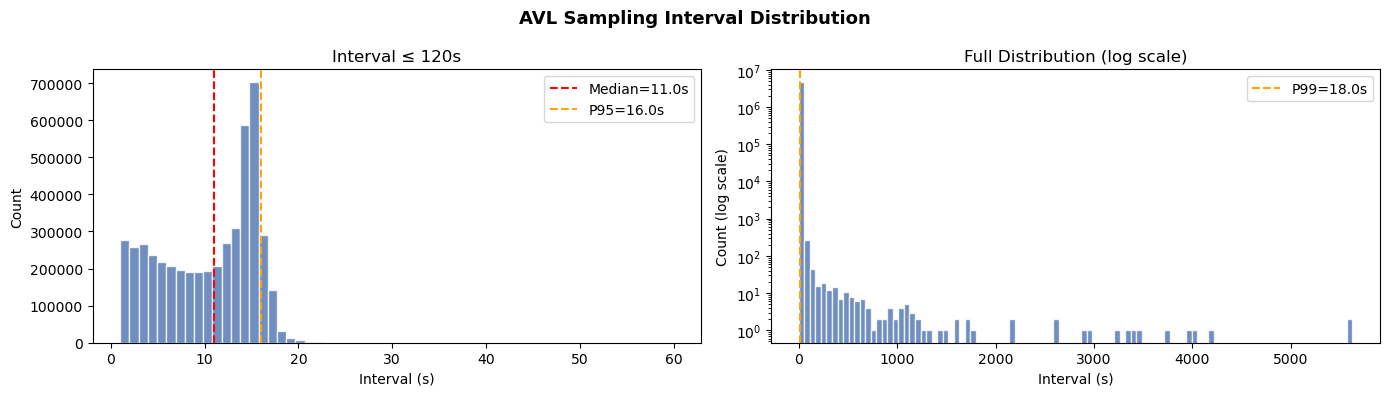

In [6]:
# Cell 2c — 可视化间隔分布
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("AVL Sampling Interval Distribution", fontsize=13, fontweight="bold")

intervals = interval_df["interval_sec"].to_numpy()

# 左图：0-60s的分布（正常范围）
ax = axes[0]
ax.hist(intervals[intervals <= 60], bins=60, color="#4C72B0", alpha=0.8, edgecolor="white")
ax.axvline(median_interval, color="red", linestyle="--", label=f"Median={median_interval:.1f}s")
ax.axvline(p95_interval, color="orange", linestyle="--", label=f"P95={p95_interval:.1f}s")
ax.set_xlabel("Interval (s)")
ax.set_ylabel("Count")
ax.set_title("Interval ≤ 120s")
ax.legend()

# 右图：完整分布（log scale，看长尾）
ax2 = axes[1]
ax2.hist(intervals, bins=100, color="#4C72B0", alpha=0.8, edgecolor="white")
ax2.set_yscale("log")
ax2.axvline(p99_interval, color="orange", linestyle="--", label=f"P99={p99_interval:.1f}s")
ax2.set_xlabel("Interval (s)")
ax2.set_ylabel("Count (log scale)")
ax2.set_title("Full Distribution (log scale)")
ax2.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/A2_sampling_interval.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Cell 2d — gap分布补充诊断（了解中断的严重程度）
gap_df = (
    interval_df.filter(pl.col("interval_sec") > 60)
    .with_columns(
        pl.col("interval_sec").alias("gap_sec")
    )
)

print(f"Gap > 60s 的记录数: {len(gap_df):,}")
print(f"Gap > 60s 的比例  : {len(gap_df)/len(interval_df):.4%}")
print(f"Gap > 300s (5min) : {gap_df.filter(pl.col('gap_sec')>300).height:,}")
print(f"Gap > 3600s (1h)  : {gap_df.filter(pl.col('gap_sec')>3600).height:,}")
print()
print("Gap > 60s 的分布：")
print(gap_df["gap_sec"].describe())

Gap > 60s 的记录数: 428
Gap > 60s 的比例  : 0.0089%
Gap > 300s (5min) : 119
Gap > 3600s (1h)  : 6

Gap > 60s 的分布：
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 428.0      │
│ null_count ┆ 0.0        │
│ mean       ┆ 373.10514  │
│ std        ┆ 719.976178 │
│ min        ┆ 61.0       │
│ 25%        ┆ 73.0       │
│ 50%        ┆ 102.0      │
│ 75%        ┆ 339.0      │
│ max        ┆ 5624.0     │
└────────────┴────────────┘


In [8]:
# Cell 2f — 验证大gap是否是trip内真实中断
# 取几个gap最大的案例，看看前后记录是否合理

large_gaps = (
    df.sort(["fahrt_id", "tst_iso"])
    .with_columns(
        pl.col("tst_iso").diff().over("fahrt_id")
        .dt.total_seconds()
        .alias("gap_sec")
    )
    .filter(pl.col("gap_sec") > 3600)  # 只看1小时以上的极端案例
    .select(["fahrt_id", "fzg_id", "linie", "tst_iso", "gap_sec"])
    .sort("gap_sec", descending=True)
)

print(f"Gap > 1h 的记录数: {len(large_gaps)}")
print(large_gaps)

# 对每个大gap，看前后各一行的上下文
for row in large_gaps.head(3).iter_rows(named=True):
    fid = row["fahrt_id"]
    ts  = row["tst_iso"]
    context = (
        df.filter(pl.col("fahrt_id") == fid)
        .sort("tst_iso")
        .select(["tst_iso", "fzg_id", "linie", "ort_nr_start"])
    )
    print(f"\nfahrt_id={fid}, gap={row['gap_sec']}s")
    print(context.head(3))
    print("...")
    print(context.tail(3))

Gap > 1h 的记录数: 6
shape: (6, 5)
┌──────────┬────────┬───────┬────────────────────────────────┬─────────┐
│ fahrt_id ┆ fzg_id ┆ linie ┆ tst_iso                        ┆ gap_sec │
│ ---      ┆ ---    ┆ ---   ┆ ---                            ┆ ---     │
│ i64      ┆ i64    ┆ i64   ┆ datetime[μs, UTC]              ┆ i64     │
╞══════════╪════════╪═══════╪════════════════════════════════╪═════════╡
│ 9716130  ┆ 888    ┆ 9     ┆ 2025-07-30 07:19:36.080489 UTC ┆ 5624    │
│ 18032130 ┆ 769    ┆ 11    ┆ 2025-07-30 08:28:27.522306 UTC ┆ 5615    │
│ 7153101  ┆ 1927   ┆ 4     ┆ 2025-08-01 03:06:06.263044 UTC ┆ 4197    │
│ 7017101  ┆ 1929   ┆ 4     ┆ 2025-08-01 06:09:14.649928 UTC ┆ 4034    │
│ 2577101  ┆ 309    ┆ 2     ┆ 2025-08-01 07:05:42.999407 UTC ┆ 3990    │
│ 17609130 ┆ 809    ┆ 11    ┆ 2025-07-30 08:28:28.516134 UTC ┆ 3743    │
└──────────┴────────┴───────┴────────────────────────────────┴─────────┘

fahrt_id=9716130, gap=5624s
shape: (3, 4)
┌────────────────────────────────┬────────┬───────

In [9]:
# Cell 2g — 验证大gap的时间规律
large_gaps_all = (
    df.sort(["fahrt_id", "tst_iso"])
    .with_columns(
        pl.col("tst_iso").diff().over("fahrt_id")
        .dt.total_seconds()
        .alias("gap_sec")
    )
    .filter(pl.col("gap_sec") > 3600)
    .with_columns(
        pl.col("tst_iso").dt.hour().alias("hour_of_day")
    )
)

print("大gap出现的小时分布（UTC）：")
print(
    large_gaps_all
    .group_by("hour_of_day")
    .count()
    .sort("hour_of_day")
)

大gap出现的小时分布（UTC）：
shape: (4, 2)
┌─────────────┬───────┐
│ hour_of_day ┆ count │
│ ---         ┆ ---   │
│ i8          ┆ u32   │
╞═════════════╪═══════╡
│ 3           ┆ 1     │
│ 6           ┆ 1     │
│ 7           ┆ 2     │
│ 8           ┆ 2     │
└─────────────┴───────┘


/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_10979/4202778495.py:19: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  .count()


In [10]:
# Cell 2 — Run analysis
result = analyze_missing(df, output_dir=OUTPUT_DIR, gap_threshold_sec=30)

print(f"核心字段完整率     : {result['core_completeness_rate']:.3%}")
print(f"Trip内记录中断次数 : {result['trip_gap_count']:,}  ({result['trip_gap_rate']:.3%})")
print(f"受影响的trip数     : {result['affected_trips']:,}")
print()
print("各字段缺失率：")
for item in result["field_missing"]:
    if item["null_rate"] > 0:
        print(f"  [{item['group']:10s}] {item['column']:25s} {item['null_rate']:.3%}")

核心字段完整率     : 100.000%
Trip内记录中断次数 : 1,739  (0.035%)
受影响的trip数     : 1,196

各字段缺失率：
  [secondary ] linie_text                0.302%
  [secondary ] zieltext                  0.302%
